## Online Retail Customer Churn Dataset 

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
df = pd.read_csv("online_retail_customer_churn.csv")

In [3]:
print(df.head())

   Customer_ID  Age Gender  Annual_Income  Total_Spend  Years_as_Customer  \
0            1   62  Other          45.15      5892.58                  5   
1            2   65   Male          79.51      9025.47                 13   
2            3   18   Male          29.19       618.83                 13   
3            4   21  Other          79.63      9110.30                  3   
4            5   21  Other          77.66      5390.88                 15   

   Num_of_Purchases  Average_Transaction_Amount  Num_of_Returns  \
0                22                      453.80               2   
1                77                       22.90               2   
2                71                       50.53               5   
3                33                      411.83               5   
4                43                      101.19               3   

   Num_of_Support_Contacts  Satisfaction_Score  Last_Purchase_Days_Ago  \
0                        0                   3              

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Customer_ID                 1000 non-null   int64  
 1   Age                         1000 non-null   int64  
 2   Gender                      1000 non-null   object 
 3   Annual_Income               1000 non-null   float64
 4   Total_Spend                 1000 non-null   float64
 5   Years_as_Customer           1000 non-null   int64  
 6   Num_of_Purchases            1000 non-null   int64  
 7   Average_Transaction_Amount  1000 non-null   float64
 8   Num_of_Returns              1000 non-null   int64  
 9   Num_of_Support_Contacts     1000 non-null   int64  
 10  Satisfaction_Score          1000 non-null   int64  
 11  Last_Purchase_Days_Ago      1000 non-null   int64  
 12  Email_Opt_In                1000 non-null   bool   
 13  Promotion_Response          1000 n

In [5]:
print(df.describe())

       Customer_ID          Age  Annual_Income  Total_Spend  \
count  1000.000000  1000.000000    1000.000000   1000.00000   
mean    500.500000    43.267000     111.962960   5080.79265   
std     288.819436    15.242311      52.844111   2862.12335   
min       1.000000    18.000000      20.010000    108.94000   
25%     250.750000    30.000000      67.800000   2678.67500   
50%     500.500000    43.000000     114.140000   4986.19500   
75%     750.250000    56.000000     158.452500   7606.47000   
max    1000.000000    69.000000     199.730000   9999.64000   

       Years_as_Customer  Num_of_Purchases  Average_Transaction_Amount  \
count        1000.000000       1000.000000                 1000.000000   
mean            9.727000         49.456000                  266.876530   
std             5.536346         28.543595                  145.873445   
min             1.000000          1.000000                   10.460000   
25%             5.000000         25.000000                  13

In [6]:
print(df.isnull().sum())

Customer_ID                   0
Age                           0
Gender                        0
Annual_Income                 0
Total_Spend                   0
Years_as_Customer             0
Num_of_Purchases              0
Average_Transaction_Amount    0
Num_of_Returns                0
Num_of_Support_Contacts       0
Satisfaction_Score            0
Last_Purchase_Days_Ago        0
Email_Opt_In                  0
Promotion_Response            0
Target_Churn                  0
dtype: int64


In [7]:
df_ch = df.copy()

In [8]:
df_ch = df_ch.drop("Customer_ID", axis=1)

In [9]:
print(df_ch.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         1000 non-null   int64  
 1   Gender                      1000 non-null   object 
 2   Annual_Income               1000 non-null   float64
 3   Total_Spend                 1000 non-null   float64
 4   Years_as_Customer           1000 non-null   int64  
 5   Num_of_Purchases            1000 non-null   int64  
 6   Average_Transaction_Amount  1000 non-null   float64
 7   Num_of_Returns              1000 non-null   int64  
 8   Num_of_Support_Contacts     1000 non-null   int64  
 9   Satisfaction_Score          1000 non-null   int64  
 10  Last_Purchase_Days_Ago      1000 non-null   int64  
 11  Email_Opt_In                1000 non-null   bool   
 12  Promotion_Response          1000 non-null   object 
 13  Target_Churn                1000 n

In [10]:
print(df_ch.dtypes)

Age                             int64
Gender                         object
Annual_Income                 float64
Total_Spend                   float64
Years_as_Customer               int64
Num_of_Purchases                int64
Average_Transaction_Amount    float64
Num_of_Returns                  int64
Num_of_Support_Contacts         int64
Satisfaction_Score              int64
Last_Purchase_Days_Ago          int64
Email_Opt_In                     bool
Promotion_Response             object
Target_Churn                     bool
dtype: object


In [11]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df_ch["Gender"] = encoder.fit_transform(df_ch["Gender"])
df_ch["Promotion_Response"] = encoder.fit_transform(df_ch["Promotion_Response"])

In [12]:
df_ch["Email_Opt_In"] = df_ch["Email_Opt_In"].astype(int)
df_ch["Target_Churn"] = df_ch["Target_Churn"].astype(int)

In [13]:
print(df_ch.dtypes)

Age                             int64
Gender                          int32
Annual_Income                 float64
Total_Spend                   float64
Years_as_Customer               int64
Num_of_Purchases                int64
Average_Transaction_Amount    float64
Num_of_Returns                  int64
Num_of_Support_Contacts         int64
Satisfaction_Score              int64
Last_Purchase_Days_Ago          int64
Email_Opt_In                    int32
Promotion_Response              int32
Target_Churn                    int32
dtype: object


In [14]:
y = df_ch["Target_Churn"]

In [15]:
X = df_ch.drop("Target_Churn", axis=1)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Decision Tree 

In [17]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(random_state=42)

In [18]:
decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [19]:
y_pred_dt = decision_tree.predict(X_test)

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred_dt)
precision = precision_score(y_test, y_pred_dt)
recall = recall_score(y_test, y_pred_dt)
f1 = f1_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Decision Tree Results
Accuracy: 0.53
Precision: 0.5588235294117647
Recall: 0.5377358490566038
F1 Score: 0.5480769230769231


In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_dt)

print(cm)

[[49 45]
 [49 57]]


In [22]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": decision_tree.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                       Feature  Importance
3                  Total_Spend    0.205570
2                Annual_Income    0.143352
10      Last_Purchase_Days_Ago    0.129634
0                          Age    0.098911
6   Average_Transaction_Amount    0.096581
5             Num_of_Purchases    0.069376
4            Years_as_Customer    0.065797
9           Satisfaction_Score    0.051122
8      Num_of_Support_Contacts    0.039579
7               Num_of_Returns    0.039410
12          Promotion_Response    0.032547
1                       Gender    0.018096
11                Email_Opt_In    0.010025


### SVM 

In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
scaler.transform(X_test)

array([[ 0.55035175,  1.25671377, -1.6712093 , ...,  0.33747406,
         0.94169658,  1.148692  ],
       [ 0.48441174,  1.25671377,  0.21176106, ...,  0.4240182 ,
         0.94169658, -1.30185094],
       [-0.7684483 ,  0.02765385, -0.84955297, ...,  0.14515375,
        -1.06191317, -1.30185094],
       ...,
       [-0.83438831,  0.02765385,  1.60322357, ..., -1.65304113,
         0.94169658, -1.30185094],
       [ 1.34163178,  0.02765385,  0.69660116, ...,  0.20284985,
        -1.06191317, -0.07657947],
       [-0.50468829, -1.20140607,  0.0945993 , ..., -0.22987085,
         0.94169658, -1.30185094]])

In [25]:
from sklearn.svm import SVC

svm_model = SVC(random_state=42)

In [26]:
svm_model.fit(X_train_scaled, y_train)

SVC(random_state=42)

In [27]:
y_pred_svm = svm_model.predict(X_test_scaled)

In [28]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print("SVM Results")
print("Accuracy:", accuracy_svm)
print("Precision:", precision_svm)
print("Recall:", recall_svm)
print("F1 Score:", f1_svm)

SVM Results
Accuracy: 0.51
Precision: 0.5307692307692308
Recall: 0.6509433962264151
F1 Score: 0.5847457627118645


In [29]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

print(cm_svm)

[[33 61]
 [37 69]]


In [30]:
print(df_ch["Target_Churn"].value_counts())

1    526
0    474
Name: Target_Churn, dtype: int64


In [31]:
print(df_ch["Target_Churn"].value_counts(normalize=True))

1    0.526
0    0.474
Name: Target_Churn, dtype: float64


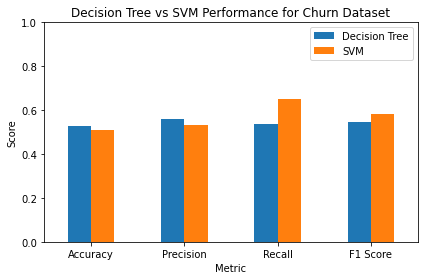

In [32]:
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Decision Tree": [accuracy, precision, recall, f1],
    "SVM": [accuracy_svm, precision_svm, recall_svm, f1_svm]
})

results.set_index("Metric").plot(kind="bar")

plt.title("Decision Tree vs SVM Performance for Churn Dataset")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

##  Retail Inventory Optimization Dataset

In [33]:
df_sales = pd.read_csv("Retail inventory.csv")

In [34]:
print(df_sales.head())

   Store        Date                       Product  Weekly_Sales  \
0      1  05-02-2010      Blueberry scented candle    1643690.90   
1      4  12-02-2010  Stainless steel water bottle    1641957.44   
2      5  19-02-2010         Leather messenger bag    1611968.17   
3      2  26-02-2010           Organic coconut oil    1409727.59   
4      3  05-03-2010    Bluetooth wireless earbuds    1554806.68   

   inventory level  Temperature  Past promotion of product in lac  \
0                0        42.31                             2.572   
1                1        38.51                             2.548   
2                0        39.93                             2.514   
3                0        46.63                             2.561   
4                0        46.50                             2.625   

   demand forecast  
0            8.106  
1            8.106  
2            8.106  
3            8.106  
4            8.106  


In [35]:
print(df_sales.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 8 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Store                             499 non-null    int64  
 1   Date                              499 non-null    object 
 2   Product                           499 non-null    object 
 3   Weekly_Sales                      499 non-null    float64
 4   inventory level                   499 non-null    int64  
 5   Temperature                       499 non-null    float64
 6   Past promotion of product in lac  499 non-null    float64
 7   demand forecast                   499 non-null    float64
dtypes: float64(4), int64(2), object(2)
memory usage: 31.3+ KB
None


In [36]:
print(df_sales.isnull().sum())

Store                               0
Date                                0
Product                             0
Weekly_Sales                        0
inventory level                     0
Temperature                         0
Past promotion of product in lac    0
demand forecast                     0
dtype: int64


In [37]:
print(df_sales.columns)

Index(['Store', 'Date', 'Product', 'Weekly_Sales', 'inventory level',
       'Temperature', 'Past promotion of product in lac', 'demand forecast'],
      dtype='object')


In [38]:
df_sl = df_sales.copy()

In [39]:
print(df_sl.dtypes)

Store                                 int64
Date                                 object
Product                              object
Weekly_Sales                        float64
inventory level                       int64
Temperature                         float64
Past promotion of product in lac    float64
demand forecast                     float64
dtype: object


In [41]:
print(df_sl.head())

   Store        Date                       Product  Weekly_Sales  \
0      1  05-02-2010      Blueberry scented candle    1643690.90   
1      4  12-02-2010  Stainless steel water bottle    1641957.44   
2      5  19-02-2010         Leather messenger bag    1611968.17   
3      2  26-02-2010           Organic coconut oil    1409727.59   
4      3  05-03-2010    Bluetooth wireless earbuds    1554806.68   

   inventory level  Temperature  Past promotion of product in lac  \
0                0        42.31                             2.572   
1                1        38.51                             2.548   
2                0        39.93                             2.514   
3                0        46.63                             2.561   
4                0        46.50                             2.625   

   demand forecast  
0            8.106  
1            8.106  
2            8.106  
3            8.106  
4            8.106  


In [42]:
print(df_sl.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 8 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Store                             499 non-null    int64  
 1   Date                              499 non-null    object 
 2   Product                           499 non-null    object 
 3   Weekly_Sales                      499 non-null    float64
 4   inventory level                   499 non-null    int64  
 5   Temperature                       499 non-null    float64
 6   Past promotion of product in lac  499 non-null    float64
 7   demand forecast                   499 non-null    float64
dtypes: float64(4), int64(2), object(2)
memory usage: 31.3+ KB
None


In [43]:
print(df_sl.isnull().sum())

Store                               0
Date                                0
Product                             0
Weekly_Sales                        0
inventory level                     0
Temperature                         0
Past promotion of product in lac    0
demand forecast                     0
dtype: int64


In [44]:
print(df_sl.dtypes)

Store                                 int64
Date                                 object
Product                              object
Weekly_Sales                        float64
inventory level                       int64
Temperature                         float64
Past promotion of product in lac    float64
demand forecast                     float64
dtype: object


In [46]:
df_sl["Date"] = pd.to_datetime(df_sl["Date"])

df_sl["Year"] = df_sl["Date"].dt.year
df_sl["Month"] = df_sl["Date"].dt.month
df_sl["Day"] = df_sl["Date"].dt.day

In [47]:
df_sl = df_sl.drop("Date", axis=1)

In [48]:
encoder = LabelEncoder()

df_sl["Product"] = encoder.fit_transform(df_sl["Product"])

In [49]:
X_sales = df_sl.drop("demand forecast", axis=1)

y_sales = df_sl["demand forecast"]

In [50]:
print(X_sales.head())
print(y_sales.head())

   Store  Product  Weekly_Sales  inventory level  Temperature  \
0      1        2    1643690.90                0        42.31   
1      4       17    1641957.44                1        38.51   
2      5       11    1611968.17                0        39.93   
3      2       13    1409727.59                0        46.63   
4      3        3    1554806.68                0        46.50   

   Past promotion of product in lac  Year  Month  Day  
0                             2.572  2010      5    2  
1                             2.548  2010     12    2  
2                             2.514  2010      2   19  
3                             2.561  2010      2   26  
4                             2.625  2010      5    3  
0    8.106
1    8.106
2    8.106
3    8.106
4    8.106
Name: demand forecast, dtype: float64


In [51]:
X_train_sales, X_test_sales, y_train_sales, y_test_sales = train_test_split(
    X_sales,
    y_sales,
    test_size=0.2,
    random_state=42
)

In [52]:
print(X_train_sales.shape)
print(X_test_sales.shape)

(399, 9)
(100, 9)


### Decision Tree

In [53]:
from sklearn.tree import DecisionTreeRegressor

decision_tree_sales = DecisionTreeRegressor(random_state=42)

decision_tree_sales.fit(X_train_sales, y_train_sales)

y_pred_dt_sales = decision_tree_sales.predict(X_test_sales)

In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_dt = mean_absolute_error(y_test_sales, y_pred_dt_sales)

rmse_dt = np.sqrt(mean_squared_error(y_test_sales, y_pred_dt_sales))

r2_dt = r2_score(y_test_sales, y_pred_dt_sales)

print("Decision Tree Regressor Results")
print("MAE:", mae_dt)
print("RMSE:", rmse_dt)
print("R²:", r2_dt)

Decision Tree Regressor Results
MAE: 0.20363000000000003
RMSE: 0.43136607423393886
R²: 0.49922897585155657


### SVM 

In [55]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

scaler_sales = StandardScaler()

X_train_sales_scaled = scaler_sales.fit_transform(X_train_sales)
X_test_sales_scaled = scaler_sales.transform(X_test_sales)

In [56]:
svr_model = SVR()

svr_model.fit(X_train_sales_scaled, y_train_sales)

y_pred_svr_sales = svr_model.predict(X_test_sales_scaled)

In [57]:
mae_svr = mean_absolute_error(y_test_sales, y_pred_svr_sales)

rmse_svr = np.sqrt(mean_squared_error(y_test_sales, y_pred_svr_sales))

r2_svr = r2_score(y_test_sales, y_pred_svr_sales)

print("SVR Results")
print("MAE:", mae_svr)
print("RMSE:", rmse_svr)
print("R²:", r2_svr)

SVR Results
MAE: 0.3269348360384317
RMSE: 0.515772705872308
R²: 0.28408092894556236


In [58]:
sales_results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Decision Tree": [mae_dt, rmse_dt, r2_dt],
    "SVR": [mae_svr, rmse_svr, r2_svr]
})

print(sales_results)

  Metric  Decision Tree       SVR
0    MAE       0.203630  0.326935
1   RMSE       0.431366  0.515773
2     R²       0.499229  0.284081


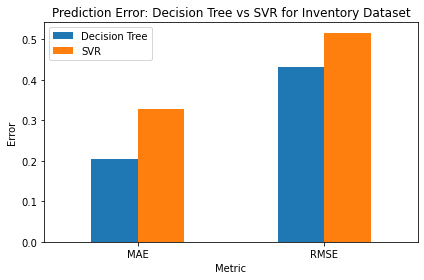

In [62]:
error_results = pd.DataFrame({
    "Metric": ["MAE", "RMSE"],
    "Decision Tree": [mae_dt, rmse_dt],
    "SVR": [mae_svr, rmse_svr]
})

error_results.set_index("Metric").plot(kind="bar")

plt.title("Prediction Error: Decision Tree vs SVR for Inventory Dataset")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

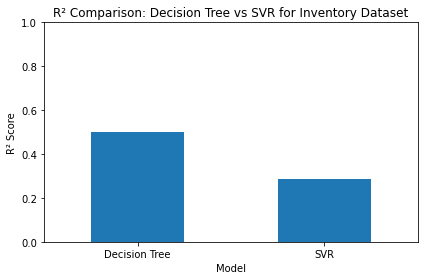

In [63]:
r2_results = pd.DataFrame({
    "Model": ["Decision Tree", "SVR"],
    "R²": [r2_dt, r2_svr]
})

r2_results.set_index("Model").plot(kind="bar")

plt.title("R² Comparison: Decision Tree vs SVR for Inventory Dataset")
plt.ylabel("R² Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend().set_visible(False)
plt.tight_layout()
plt.show()

In [64]:
feature_importance_sales = pd.DataFrame({
    "Feature": X_sales.columns,
    "Importance": decision_tree_sales.feature_importances_
})

feature_importance_sales = feature_importance_sales.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance_sales)

                            Feature  Importance
6                              Year    0.448097
2                      Weekly_Sales    0.197695
5  Past promotion of product in lac    0.135065
4                       Temperature    0.111649
7                             Month    0.041480
1                           Product    0.039581
8                               Day    0.018358
3                   inventory level    0.004706
0                             Store    0.003367
